## Linear regression of input/output voltage

In [1]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

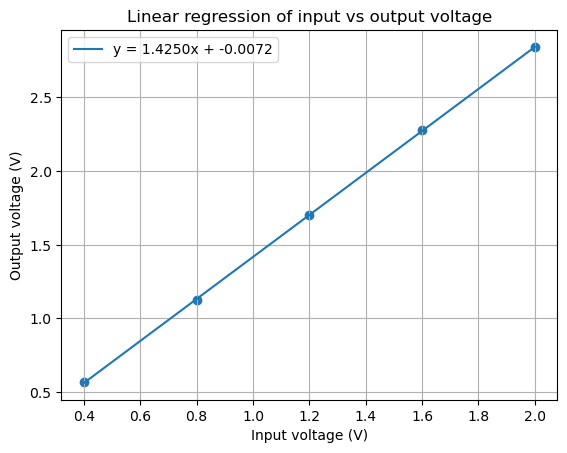

In [3]:
x = np.array([2.0, 1.6, 1.2, 0.8, 0.4])
y = np.array([2.84, 2.28, 1.70, 1.128, 0.566])

slope, intercept, r_value, p_value, std_err = linregress(x, y)

y_fit = slope * x + intercept

plt.scatter(x, y)
plt.plot(x, y_fit, label=f'y = {slope:.4f}x + {intercept:.4f}')
plt.xlabel('Input voltage (V)')
plt.ylabel('Output voltage (V)')
plt.title('Linear regression of input vs output voltage')
plt.legend()
plt.grid(True)
plt.show()

## Key rate over distance

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [5]:
@dataclass
class ChannelParams:
    u: float          # excess photons / excess noise
    eta: float        # channel eta
    t: float          # electronic noise
    tau: float        # tau parameter
    NnB2B: float      # photon number / modulation variance

In [6]:
def compute_key_rate(
    MI_chunk: float,
    I_YE: float,
    beta: float,
) -> float:
    
    return beta * MI_chunk - I_YE

In [7]:
def hol_g(x: float | np.ndarray) -> float | np.ndarray:

    x = np.asarray(x)

    return np.where(
        x > 0,
        (x + 1) * np.log2(x + 1) - x * np.log2(x),
        0.0,
    )

In [8]:
def get_holevo(params: ChannelParams | tuple) -> float:

    if isinstance(params, ChannelParams):
        eta = params.eta
        tau = params.tau
        excess_photons = params.u
        t = params.t
        Nphoton = params.NnB2B
        T = eta * tau

    elif isinstance(params, (tuple, list)) and len(params) == 6:
        eta, tau, excess_photons, t, Nphoton, T = params

    else:
        raise ValueError("Expected ChannelParams or tuple/list of 6 values.")

    Q = (1 - eta) * tau / (1 + excess_photons + t + T * Nphoton)
    w = excess_photons / (tau * (1 - eta))

    a1 = (1 - eta) * Nphoton + eta * w + 0.5
    b1 = w + 0.5
    c1 = np.sqrt(eta * w * (1 + w))

    a2 = (
        (1 - eta) * Nphoton
        + eta * w
        + 0.5
        - eta * Q * (Nphoton - w) ** 2
    )

    b2 = w + 0.5 - w * (1 + w) * Q
    c2 = np.sqrt(eta * w * (1 + w)) * (1 + (Nphoton - w) * Q)

    v1_plus = 0.5 * np.abs(a1 - b1 + np.sqrt((a1 + b1) ** 2 - 4 * c1**2))
    v1_minus = 0.5 * np.abs(a1 - b1 - np.sqrt((a1 + b1) ** 2 - 4 * c1**2))

    v2_plus = 0.5 * np.abs(a2 - b2 + np.sqrt((a2 + b2) ** 2 - 4 * c2**2))
    v2_minus = 0.5 * np.abs(a2 - b2 - np.sqrt((a2 + b2) ** 2 - 4 * c2**2))

    I_YE = (
        hol_g(v1_plus - 0.5)
        + hol_g(v1_minus - 0.5)
        - hol_g(v2_plus - 0.5)
        - hol_g(v2_minus - 0.5)
    )

    return float(I_YE)

In [9]:
def key_rate_vs_noise(
    MI_chunk: float,
    eta: float,
    Velec_avg: float,
    tau: float,
    NnB2B: float,
    beta: float,
    noise_values: np.ndarray,
):
    key_rates = []

    for noise in noise_values:
        peQch = ChannelParams(
            u=noise,
            eta=eta,
            t=Velec_avg,
            tau=tau,
            NnB2B=NnB2B,
        )

        I_YE = get_holevo(peQch)
        K = compute_key_rate(MI_chunk, I_YE, beta)

        key_rates.append(K)

    return np.array(key_rates)

In [10]:
def compute_chunk_values(
    seg_ref: np.ndarray,
    seg_rx: np.ndarray,
    SNU_I: float,
    SNU_Q: float,
    VelecI: float,
    VelecQ: float,
    NnB2B: float,
    tauAvg: float,
) -> dict:

    data = np.column_stack([
        np.real(seg_ref),
        np.imag(seg_ref),
        np.real(seg_rx),
        np.imag(seg_rx),
    ])

    C = np.cov(data, rowvar=False)

    xI = C[0, 0]
    xQ = C[1, 1]

    yI = C[2, 2]
    yQ = C[3, 3]

    zI = C[0, 2]
    zQ = C[1, 3]

    zAvg = 0.5 * (abs(zI) + abs(zQ))
    xAvg = 0.5 * (xI + xQ)
    yAvg = 0.5 * (yI + yQ)
    VshotAvg = 0.5 * (SNU_I + SNU_Q)

    EN_I = (yI - (zI**2) / xI) / SNU_I - 1 - VelecI
    EN_Q = (yQ - (zQ**2) / xQ) / SNU_Q - 1 - VelecQ

    etaAvg_chunk = (zAvg**2) / (xAvg * NnB2B * VshotAvg * tauAvg)

    MI_chunk = -np.log2(1 - zAvg**2 / (xAvg * yAvg))

    return {
        "C": C,
        "xI": xI,
        "xQ": xQ,
        "yI": yI,
        "yQ": yQ,
        "zI": zI,
        "zQ": zQ,
        "zAvg": zAvg,
        "xAvg": xAvg,
        "yAvg": yAvg,
        "VshotAvg": VshotAvg,
        "EN_I": EN_I,
        "EN_Q": EN_Q,
        "etaAvg_chunk": etaAvg_chunk,
        "MI_chunk": MI_chunk,
    }


In [11]:
def key_rate_vs_noise(
    MI_chunk: float,
    eta: float,
    Velec_avg: float,
    tau: float,
    NnB2B: float,
    beta: float,
    noise_values: np.ndarray,
):
    key_rates = []

    for noise in noise_values:
        peQch = ChannelParams(
            u=noise,
            eta=eta,
            t=Velec_avg,
            tau=tau,
            NnB2B=NnB2B,
        )

        I_YE = get_holevo(peQch)
        K = compute_key_rate(MI_chunk, I_YE, beta)

        key_rates.append(K)

    return np.array(key_rates)

/tmp/ipykernel_5912/1320452365.py:37: RuntimeWarning: invalid value encountered in sqrt
  v2_plus = 0.5 * np.abs(a2 - b2 + np.sqrt((a2 + b2) ** 2 - 4 * c2**2))
/tmp/ipykernel_5912/1320452365.py:38: RuntimeWarning: invalid value encountered in sqrt
  v2_minus = 0.5 * np.abs(a2 - b2 - np.sqrt((a2 + b2) ** 2 - 4 * c2**2))


MI_chunk: 5.501949
I_YE:     5.346689
Key rate: -0.119837


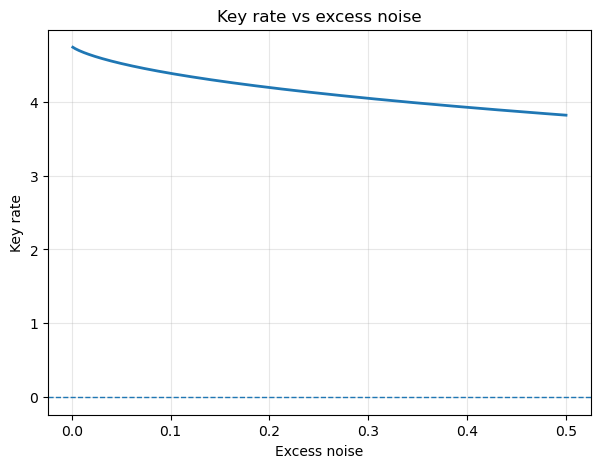

In [12]:
if __name__ == "__main__":
    seg_ref = np.array([1 + 0.2j, 2 + 0.1j, 3 + 0.4j])
    seg_rx = np.array([0.9 + 0.3j, 2.1 + 0.2j, 2.8 + 0.5j])

    SNU_I = 1.0
    SNU_Q = 1.0
    VelecI = 0.01
    VelecQ = 0.01
    NnB2B = 5.0
    tauAvg = 0.68
    beta = 0.95

    chunk = compute_chunk_values(
        seg_ref=seg_ref,
        seg_rx=seg_rx,
        SNU_I=SNU_I,
        SNU_Q=SNU_Q,
        VelecI=VelecI,
        VelecQ=VelecQ,
        NnB2B=NnB2B,
        tauAvg=tauAvg,
    )

    peQch = ChannelParams(
        u=0.5 * (chunk["EN_I"] + chunk["EN_Q"]),
        eta=chunk["etaAvg_chunk"],
        t=0.5 * (VelecI + VelecQ),
        tau=0.68,
        NnB2B=NnB2B,
    )

    I_YE = get_holevo(peQch)
    key_rate = compute_key_rate(chunk["MI_chunk"], I_YE, beta)

    print(f"MI_chunk: {chunk['MI_chunk']:.6f}")
    print(f"I_YE:     {I_YE:.6f}")
    print(f"Key rate: {key_rate:.6f}")

    noise_values = np.linspace(0.001, 0.5, 400)

    Velec_avg = 0.5 * (VelecI + VelecQ)

    key_rates = key_rate_vs_noise(
        MI_chunk=chunk["MI_chunk"],
        eta=chunk["etaAvg_chunk"],
        Velec_avg=Velec_avg,
        tau=0.68,
        NnB2B=NnB2B,
        beta=beta,
        noise_values=noise_values,
    )

    plt.figure(figsize=(7, 5))
    plt.plot(noise_values, key_rates, linewidth=2)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Excess noise")
    plt.ylabel("Key rate")
    plt.title("Key rate vs excess noise")
    plt.grid(True, alpha=0.3)

    plt.show()